In [1]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import time

In [2]:

X,y = load_diabetes(return_X_y=True)

In [3]:

print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [4]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [5]:
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [6]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [7]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.4399338661568968

In [13]:
class SGDRegressor :

    def __init__(self,learning_rate = 0.01,epochs = 100):
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X_train,y_train):
        #init your coeff
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1]) # qki no of coef no of column ke barabar hi hai isme

        for i in range(self.epochs):
            for j in range(X_train.shape[0]): # qki isme ham har row ke bad update karte hai 
                idx = np.random.randint(0,X_train.shape[0])  # qki isme koi bhi row randomly select hota hai sequence wise nahi hota hai 

                y_hat = np.dot(X_train[idx],self.coef_) + self.intercept_

                intercept_der = -2 * (y_train[idx] - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)

                coef_der = -2*np.dot((y_train[idx]-y_hat) , X_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef_der)

        print(self.intercept_,self.coef_)

    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_
                

In [18]:

sgd = SGDRegressor(learning_rate=0.01,epochs=200)

In [22]:
sgd.fit(X_train,y_train)

140.61155912498188 [   5.55607284 -194.64590458  517.2660948   332.17909336  -50.45802088
 -121.4819491  -192.23582769   94.73883937  477.41665322   85.20018433]


In [23]:

y_pred = sgd.predict(X_test)

In [24]:
r2_score(y_test,y_pred)

0.4255116100579426

In [25]:
from sklearn.linear_model import SGDRegressor

In [26]:
reg = SGDRegressor(max_iter=100,learning_rate='constant',eta0=0.01)

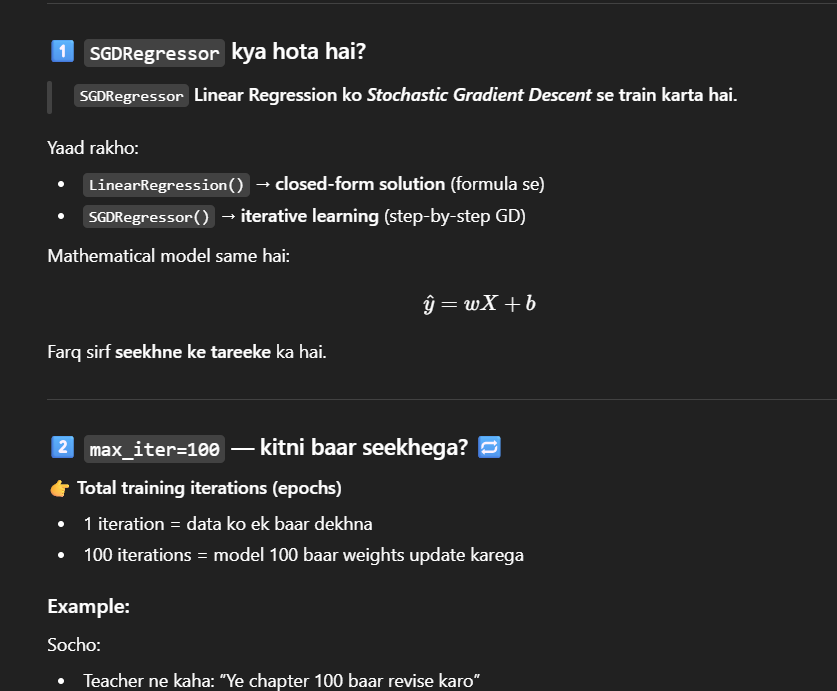

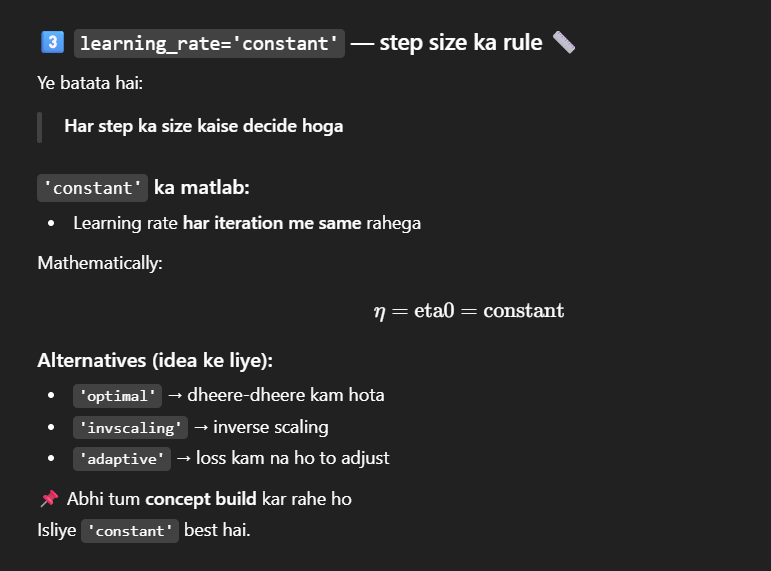

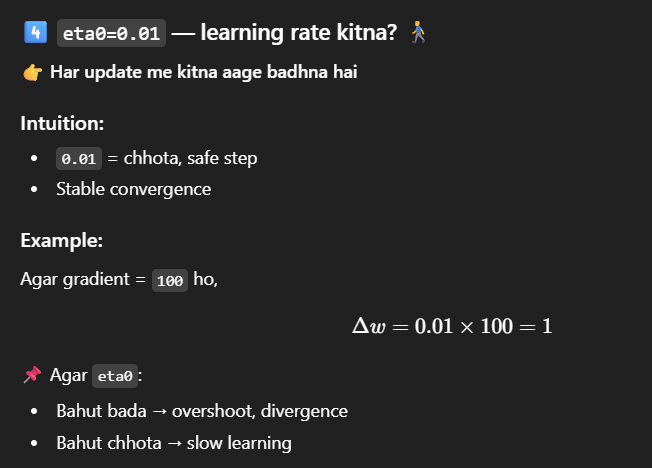

In [27]:

reg.fit(X_train,y_train)

C:\Users\vishal vishwakarma\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGDRegressor(learning_rate='constant', max_iter=100)

In [28]:
y_pred = reg.predict(X_test)

In [29]:
r2_score(y_test,y_pred)

0.42878800946683004